In [16]:
# ============================================================
# 1. IMPORTS & SETUP
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
DATA_DIR = "/kaggle/input/datasets/mohitagarwal17/dog-emotion-datasetcleaned-version/Final dog dataset/Final dog dataset"
class_names = sorted(os.listdir(DATA_DIR))
print(class_names)

# just checking how balanced the classes are
for c in class_names:
    n = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(c, n)

['angry', 'happy', 'relaxed', 'sad']
angry 931
happy 989
relaxed 979
sad 977


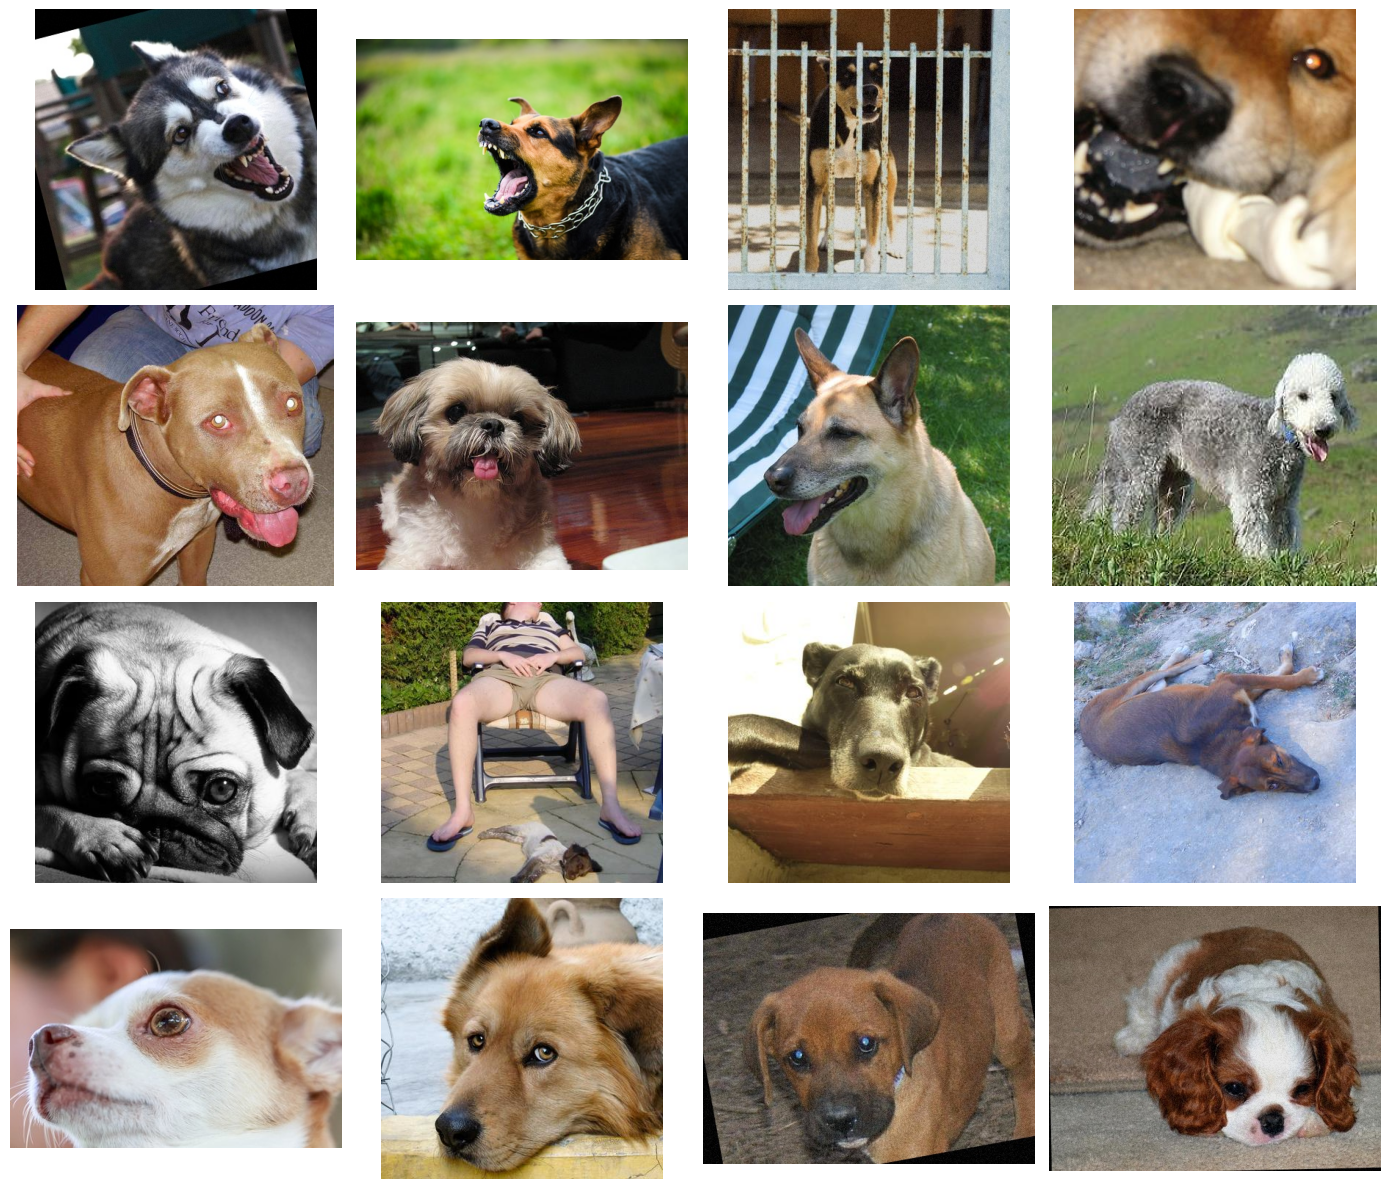

In [18]:
fig, axes = plt.subplots(len(class_names), 4, figsize=(14, 12))
for row, c in enumerate(class_names):
    folder = os.path.join(DATA_DIR, c)
    files = os.listdir(folder)[:4]
    for col, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(c)
plt.tight_layout()
plt.show()

In [19]:
IMG_SIZE = (160, 160)
BATCH = 32
SEED = 42

# -----------------------------
# 1. 70% Training
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

# -----------------------------
# 2. 30% Temporary Set
#    = 15% Validation + 15% Test
# -----------------------------
temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

# -----------------------------
# 3. Split temporary 30%
#    into 15% Validation
#    and 15% Test
# -----------------------------
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_batches = temp_batches // 2

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

# -----------------------------
# 4. Performance optimization
# -----------------------------
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

# -----------------------------
# 5. Data Augmentation
# -----------------------------
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
])

Found 3876 files belonging to 4 classes.
Using 2714 files for training.
Found 3876 files belonging to 4 classes.
Using 1162 files for validation.


In [20]:
def make_baseline():
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = augment(inp)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(len(class_names), activation="softmax")(x)

    return models.Model(inp, out)

baseline = make_baseline()
baseline.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2)
]

hist_baseline = baseline.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.2701 - loss: 1.3862 - val_accuracy: 0.3299 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3073 - loss: 1.3666 - val_accuracy: 0.3073 - val_loss: 1.3562 - learning_rate: 0.0010
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3176 - loss: 1.3505 - val_accuracy: 0.3490 - val_loss: 1.3206 - learning_rate: 0.0010
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3519 - loss: 1.3350 - val_accuracy: 0.3715 - val_loss: 1.2946 - learning_rate: 0.0010
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3674 - loss: 1.3246 - val_accuracy: 0.3958 - val_loss: 1.2850 - learning_rate: 0.0010
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3755 - loss: 1.3126 - val_accuracy: 0.4097 - val_loss: 1.2891 - learning_rate: 0.0010
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3725 - loss: 1.3089 - val_acc

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4539 - loss: 1.2023
baseline test accuracy: 0.45392492413520813
              precision    recall  f1-score   support

       angry       0.32      0.36      0.34       137
       happy       0.54      0.53      0.53       156
     relaxed       0.51      0.65      0.57       139
         sad       0.43      0.28      0.34       154

    accuracy                           0.45       586
   macro avg       0.45      0.46      0.45       586
weighted avg       0.45      0.45      0.45       586



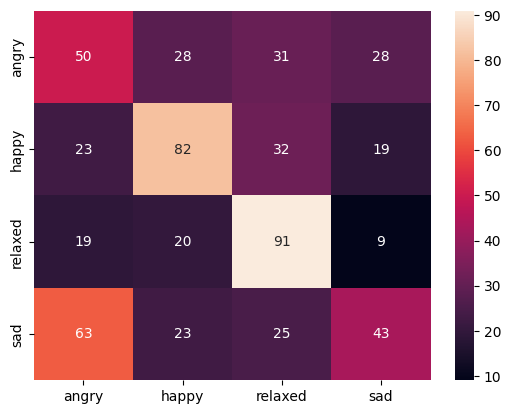

In [22]:
loss, acc = baseline.evaluate(test_ds)
print("baseline test accuracy:", acc)

y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = baseline.predict(imgs, verbose=0)
    y_true += list(np.argmax(labels, axis=1))
    y_pred += list(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.show()

In [23]:
from tensorflow.keras.regularizers import l2

def make_baseline():
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = augment(inp)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same", kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same", kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)   # heaviest dropout right before output — this is where overfitting usually happens
    out = layers.Dense(len(class_names), activation="softmax")(x)

    return models.Model(inp, out)

baseline = make_baseline()
baseline.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 259,268 (1012.77 KB)

 Trainable params: 258,564 (1010.02 KB)

 Non-trainable params: 704 (2.75 KB)

In [24]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
]

hist_baseline = baseline.fit(train_ds, validation_data=val_ds, epochs=60, callbacks=callbacks)

Epoch 1/60


E0000 00:00:1786791516.924722      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_17_1/dropout_22_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.2985 - loss: 1.5318 - val_accuracy: 0.2587 - val_loss: 1.4869 - learning_rate: 0.0010
Epoch 2/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3375 - loss: 1.4025 - val_accuracy: 0.2587 - val_loss: 1.7045 - learning_rate: 0.0010
Epoch 3/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3710 - loss: 1.3805 - val_accuracy: 0.2569 - val_loss: 1.5175 - learning_rate: 0.0010
Epoch 4/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3990 - loss: 1.3192 - val_accuracy: 0.4097 - val_loss: 1.3280 - learning_rate: 0.0010
Epoch 5/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4182 - loss: 1.3087 - val_accuracy: 0.3108 - val_loss: 1.3865 - learning_rate: 0.0010
Epoch 6/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4237 - loss: 1.3011 - val_accuracy: 0.4427 - val_loss: 1.2435 - learning_rate: 0.0010
Epoch 7/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4211 - loss: 1.2806 - val_accuracy: 0.3

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6195 - loss: 0.9961
baseline test loss: 0.9960588812828064
baseline test accuracy: 0.6194539070129395
              precision    recall  f1-score   support

       angry       0.53      0.68      0.59       137
       happy       0.65      0.65      0.65       156
     relaxed       0.64      0.56      0.60       139
         sad       0.68      0.59      0.63       154

    accuracy                           0.62       586
   macro avg       0.63      0.62      0.62       586
weighted avg       0.63      0.62      0.62       586



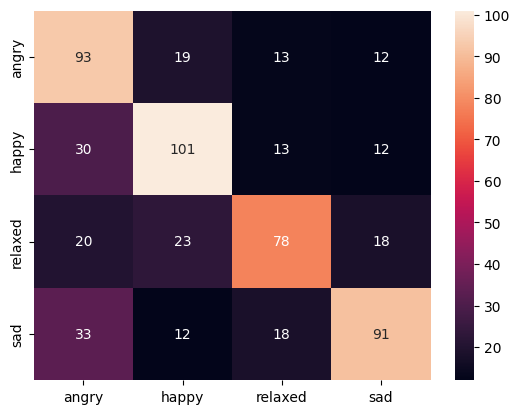

In [25]:
loss, acc = baseline.evaluate(test_ds)
print("baseline test loss:", loss)
print("baseline test accuracy:", acc)

y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = baseline.predict(imgs, verbose=0)
    y_true += list(np.argmax(labels, axis=1))
    y_pred += list(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.show()

Pretrained models

In [26]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50, Xception, InceptionV3
from tensorflow.keras.applications import mobilenet_v2, efficientnet, resnet50, xception, inception_v3

# each entry: (model class, its preprocess_input fn, input size it expects)
backbones = {
    "MobileNetV2":   (MobileNetV2,   mobilenet_v2.preprocess_input,   (160, 160)),
    "EfficientNetB0":(EfficientNetB0,efficientnet.preprocess_input,   (224, 224)),
    "ResNet50":      (ResNet50,      resnet50.preprocess_input,       (224, 224)),
    "Xception":      (Xception,      xception.preprocess_input,       (224, 224)),
    "InceptionV3":   (InceptionV3,   inception_v3.preprocess_input,   (299, 299)),
}

In [27]:
def build_and_train(
    name,
    ModelClass,
    preprocess_fn,
    img_size,
    train_ds,
    val_ds,
    test_ds
):
    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    # ========================================================
    # Resize the SAME fixed datasets for this backbone
    # ========================================================

    def resize_dataset(dataset):
        return dataset.map(
            lambda images, labels: (
                tf.image.resize(images, img_size),
                labels
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        ).prefetch(tf.data.AUTOTUNE)

    train_data = resize_dataset(train_ds)
    val_data = resize_dataset(val_ds)
    test_data = resize_dataset(test_ds)


    # ========================================================
    # Data augmentation
    # ========================================================

    model_augment = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1)
    ])


    # ========================================================
    # Load pretrained backbone
    # ========================================================

    base = ModelClass(
        input_shape=(*img_size, 3),
        include_top=False,
        weights="imagenet"
    )

    base.trainable = False


    # ========================================================
    # Build full model
    # ========================================================

    inputs = layers.Input(
        shape=(*img_size, 3)
    )

    x = model_augment(inputs)

    x = preprocess_fn(x)

    x = base(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    )(x)

    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        len(class_names),
        activation="softmax"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )


    # ========================================================
    # Stage 1 — Train classification head
    # ========================================================

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    history1 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=30,
        callbacks=[
            early_stop,
            reduce_lr
        ]
    )


    # ========================================================
    # Stage 2 — Fine-tune last 30 layers
    # ========================================================

    base.trainable = True

    for layer in base.layers[:-30]:
        layer.trainable = False


    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )


    history2 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=40,
        initial_epoch=history1.epoch[-1] + 1,
        callbacks=[
            early_stop,
            reduce_lr
        ]
    )


    # ========================================================
    # Validation evaluation
    # Used for model comparison/selection
    # ========================================================

    val_loss, val_acc = model.evaluate(
        val_data,
        verbose=0
    )


    # ========================================================
    # FINAL TEST evaluation
    # Test set is NOT used for model selection
    # ========================================================

    test_loss, test_acc = model.evaluate(
        test_data,
        verbose=0
    )

    print(
        f"{name} -> "
        f"Validation Accuracy: {val_acc:.4f} | "
        f"Test Accuracy: {test_acc:.4f}"
    )


    return (
        model,
        val_data,
        test_data,
        val_acc,
        val_loss,
        test_acc,
        test_loss,
        history1,
        history2
    )

In [28]:
results = {}
trained_models = {}

for name, (ModelClass, preprocess_fn, img_size) in backbones.items():

    (
        model,
        val_data,
        test_data,
        val_acc,
        val_loss,
        test_acc,
        test_loss,
        history1,
        history2
    ) = build_and_train(
        name,
        ModelClass,
        preprocess_fn,
        img_size,
        train_ds,
        val_ds,
        test_ds
    )

    results[name] = {
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        "test_accuracy": test_acc,
        "test_loss": test_loss
    }

    trained_models[name] = {
        "model": model,
        "val_data": val_data,
        "test_data": test_data,
        "history1": history1,
        "history2": history2
    }


results_df = pd.DataFrame(results).T

print(results_df)


Training: MobileNetV2
Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.4853 - loss: 1.2385 - val_accuracy: 0.6493 - val_loss: 0.9058 - learning_rate: 0.0010
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6363 - loss: 0.9058 - val_accuracy: 0.6406 - val_loss: 0.8688 - learning_rate: 0.0010
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6721 - loss: 0.8300 - val_accuracy: 0.6528 - val_loss: 0.8387 - learning_rate: 0.0010
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7049 - loss: 0.7707 - val_accuracy: 0.7083 - val_loss: 0.7874 - learning_rate: 0.0010
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7122 - loss: 0.7475 - val_accuracy: 0.6944 - val_loss: 0.7764 - learning_rate: 0.0010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7211 - loss: 0.7110 - val_accuracy: 0.7083 - val_loss: 0.7492 - learning_rate: 0.0010
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7399 

E0000 00:00:1786791809.699694      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_21_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.5306 - loss: 1.1001 - val_accuracy: 0.7031 - val_loss: 0.7961 - learning_rate: 0.0010
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.6916 - loss: 0.8004 - val_accuracy: 0.7083 - val_loss: 0.7414 - learning_rate: 0.0010
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.7281 - loss: 0.7129 - val_accuracy: 0.7448 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.7528 - loss: 0.6584 - val_accuracy: 0.7448 - val_loss: 0.6603 - learning_rate: 0.0010
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.7716 - loss: 0.6185 - val_accuracy: 0.7517 - val_loss: 0.6422 - learning_rate: 0.0010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.7763 - loss: 0.5922 - val_accuracy: 0.7622 - val_loss: 0.6195 - learning_rate: 0.0010
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.7874 - loss: 0.5511 - val_accuracy: 0.

E0000 00:00:1786791999.710686      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_21_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


85/85 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.7517 - loss: 0.6862 - val_accuracy: 0.8385 - val_loss: 0.4914 - learning_rate: 1.0000e-05
Epoch 32/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.7756 - loss: 0.6083 - val_accuracy: 0.8403 - val_loss: 0.4989 - learning_rate: 1.0000e-05
Epoch 33/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.7889 - loss: 0.6009 - val_accuracy: 0.8385 - val_loss: 0.5067 - learning_rate: 1.0000e-05
Epoch 34/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.7996 - loss: 0.5688 - val_accuracy: 0.8333 - val_loss: 0.5098 - learning_rate: 1.0000e-05
Epoch 35/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8084 - loss: 0.5209 - val_accuracy: 0.8316 - val_loss: 0.5095 - learning_rate: 5.0000e-06
Epoch 36/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8143 - loss: 0.5284 - val_accuracy: 0.8385 - val_loss: 0.5063 - learning_rate: 5.0000e-06
Epoch 37/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.8169 - l

Ensembling: EfficientNetB0 (224, 224) + ResNet50 (224, 224)


Model: "EfficientNetB0_ResNet50_Ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_15       │ (None, 224, 224,  │          0 │ input_2[0][0]     │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 224, 224)  │          0 │ sequential_15[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 224, 224)  │          0 │ sequential_15[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 224, 224)  │          0 │ sequential_15[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_1             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 224, 224,  │          0 │ get_item_9[0][0], │
│                     │ 3)                │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_14       │ (None, 224, 224,  │          0 │ input_1[0][0]     │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 224, 224,  │          0 │ stack_3[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ sequential_14[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_27[0][0]      │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 1280)      │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 2048)      │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 128)       │    163,968 │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 128)       │    262,272 │ dropout_39[0][0]

 Total params: 28,096,935 (107.18 MB)

 Trainable params: 459,652 (1.75 MB)

...

Epoch 1/30


E0000 00:00:1786793347.071448      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_ResNet50_Ensemble_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


85/85 ━━━━━━━━━━━━━━━━━━━━ 40s 232ms/step - accuracy: 0.4705 - loss: 1.2944 - val_accuracy: 0.7135 - val_loss: 0.8425 - learning_rate: 0.0010
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.6536 - loss: 0.9354 - val_accuracy: 0.7431 - val_loss: 0.7181 - learning_rate: 0.0010
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.7074 - loss: 0.8079 - val_accuracy: 0.7830 - val_loss: 0.6375 - learning_rate: 0.0010
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 0.7358 - loss: 0.7569 - val_accuracy: 0.7743 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.7535 - loss: 0.6937 - val_accuracy: 0.7795 - val_loss: 0.6143 - learning_rate: 0.0010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - accuracy: 0.7981 - loss: 0.6255 - val_accuracy: 0.7847 - val_loss: 0.5906 - learning_rate: 0.0010
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.8047 - loss: 0.5825 - val_

E0000 00:00:1786793588.097213      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_ResNet50_Ensemble_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


85/85 ━━━━━━━━━━━━━━━━━━━━ 45s 252ms/step - accuracy: 0.8500 - loss: 0.4747 - val_accuracy: 0.8299 - val_loss: 0.5206 - learning_rate: 1.0000e-05
Epoch 18/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.8607 - loss: 0.4402 - val_accuracy: 0.8333 - val_loss: 0.4997 - learning_rate: 1.0000e-05
Epoch 19/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.8806 - loss: 0.3935 - val_accuracy: 0.8351 - val_loss: 0.5092 - learning_rate: 1.0000e-05
Epoch 20/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.8769 - loss: 0.3830 - val_accuracy: 0.8368 - val_loss: 0.5030 - learning_rate: 1.0000e-05
Epoch 21/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.8873 - loss: 0.3620 - val_accuracy: 0.8368 - val_loss: 0.4809 - learning_rate: 1.0000e-05
Epoch 22/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.8950 - loss: 0.3468 - val_accuracy: 0.8351 - val_loss: 0.4938 - learning_rate: 1.0000e-05
Epoch 23/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy

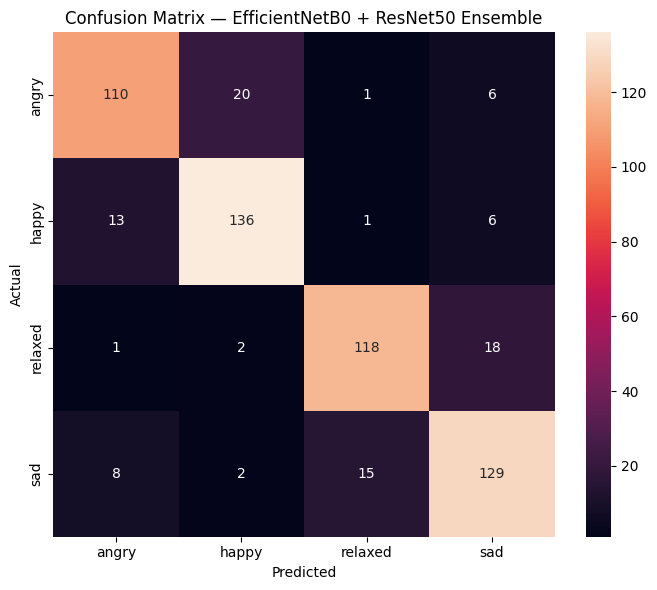

In [29]:
# ============================================================
# 1. Select the top 2 backbones USING VALIDATION ACCURACY
# ============================================================

results_sorted = results_df.sort_values(
    "val_accuracy",
    ascending=False
)

model1_name = results_sorted.index[0]
model2_name = results_sorted.index[1]

ModelClass1, preprocess_fn1, size1 = backbones[model1_name]
ModelClass2, preprocess_fn2, size2 = backbones[model2_name]

print(
    f"Ensembling: "
    f"{model1_name} {size1} + "
    f"{model2_name} {size2}"
)


# ============================================================
# 2. Build the two pretrained backbones
# ============================================================

base1 = ModelClass1(
    input_shape=(*size1, 3),
    include_top=False,
    weights="imagenet"
)

base2 = ModelClass2(
    input_shape=(*size2, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze both backbones initially
base1.trainable = False
base2.trainable = False


# ============================================================
# 3. Define separate inputs
# ============================================================

input1 = layers.Input(
    shape=(*size1, 3),
    name="input_1"
)

input2 = layers.Input(
    shape=(*size2, 3),
    name="input_2"
)


# ============================================================
# 4. Data augmentation
# ============================================================

augment1 = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1)
])

augment2 = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1)
])


# ============================================================
# 5. First backbone
# ============================================================

x1 = augment1(input1)

x1 = preprocess_fn1(x1)

x1 = base1(
    x1,
    training=False
)

x1 = layers.GlobalAveragePooling2D()(x1)

x1 = layers.Dropout(0.3)(x1)

x1 = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x1)

x1 = layers.Dropout(0.4)(x1)


# ============================================================
# 6. Second backbone
# ============================================================

x2 = augment2(input2)

x2 = preprocess_fn2(x2)

x2 = base2(
    x2,
    training=False
)

x2 = layers.GlobalAveragePooling2D()(x2)

x2 = layers.Dropout(0.3)(x2)

x2 = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(x2)

x2 = layers.Dropout(0.4)(x2)


# ============================================================
# 7. Combine feature representations
# ============================================================

combined = layers.Concatenate()([
    x1,
    x2
])

combined = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(1e-4)
)(combined)

combined = layers.Dropout(0.5)(combined)

outputs = layers.Dense(
    len(class_names),
    activation="softmax",
    name="output"
)(combined)


# ============================================================
# 8. Create ensemble model
# ============================================================

ensemble_model = models.Model(
    inputs=[input1, input2],
    outputs=outputs,
    name=f"{model1_name}_{model2_name}_Ensemble"
)

ensemble_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ensemble_model.summary()


# ============================================================
# 9. Prepare the FIXED datasets for both input sizes
# ============================================================

def prepare_ensemble_dataset(dataset):

    def resize_images(imgs, labels):

        imgs1 = tf.image.resize(
            imgs,
            size1
        )

        imgs2 = tf.image.resize(
            imgs,
            size2
        )

        return (
            (imgs1, imgs2),
            labels
        )

    return dataset.map(
        resize_images,
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)


# IMPORTANT:
# These are the SAME train/validation/test images
# created earlier. No new split is performed.

ensemble_train = prepare_ensemble_dataset(train_ds)

ensemble_val = prepare_ensemble_dataset(val_ds)

ensemble_test = prepare_ensemble_dataset(test_ds)


# ============================================================
# 10. Train ensemble classification head
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history1 = ensemble_model.fit(
    ensemble_train,
    validation_data=ensemble_val,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)


# ============================================================
# 11. Fine-tune both backbones
# ============================================================

base1.trainable = True
base2.trainable = True


# Freeze earlier layers
for layer in base1.layers[:-30]:
    layer.trainable = False

for layer in base2.layers[:-30]:
    layer.trainable = False


# Keep BatchNorm layers frozen during fine-tuning
for layer in base1.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

for layer in base2.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False


# Recompile with small learning rate
ensemble_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 12. Fine-tune
# ============================================================

history2 = ensemble_model.fit(
    ensemble_train,
    validation_data=ensemble_val,
    epochs=40,
    initial_epoch=history1.epoch[-1] + 1,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)


# ============================================================
# 13. Validation evaluation
# ============================================================

val_loss, val_acc = ensemble_model.evaluate(
    ensemble_val,
    verbose=0
)

print("\n" + "=" * 55)
print("ENSEMBLE VALIDATION RESULTS")
print("=" * 55)

print(f"Model 1          : {model1_name}")
print(f"Model 2          : {model2_name}")
print(f"Validation Loss  : {val_loss:.4f}")
print(f"Validation Acc.  : {val_acc:.4f}")


# ============================================================
# 14. FINAL evaluation on the untouched TEST set
# ============================================================

test_loss, test_acc = ensemble_model.evaluate(
    ensemble_test,
    verbose=0
)

print("\n" + "=" * 55)
print("FINAL ENSEMBLE TEST RESULTS")
print("=" * 55)

print(f"Model 1       : {model1_name}")
print(f"Model 2       : {model2_name}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


# ============================================================
# 15. Generate predictions on TEST set
# ============================================================

y_true = []
y_pred = []

for (imgs1, imgs2), labels in ensemble_test:

    preds = ensemble_model.predict(
        [imgs1, imgs2],
        verbose=0
    )

    y_true.extend(
        np.argmax(
            labels.numpy(),
            axis=1
        )
    )

    y_pred.extend(
        np.argmax(
            preds,
            axis=1
        )
    )


# ============================================================
# 16. Classification report
# ============================================================

print("\nClassification Report — Ensemble\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


# ============================================================
# 17. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix — "
    f"{model1_name} + {model2_name} Ensemble"
)

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# FINAL EVALUATION — ALL MODELS
# Validation Loss, Validation Accuracy,
# Test Loss and Test Accuracy
# ============================================================

models_to_eval = {
    "Baseline CNN": (baseline, val_ds, test_ds),
    **{
        name: (info["model"], info["val_data"], info["test_data"])
        for name, info in trained_models.items()
    },
    f"Ensemble ({model1_name}+{model2_name})":
        (ensemble_model, ensemble_val, ensemble_test)
}

final_metrics = {}

for name, (model, val_data, test_data) in models_to_eval.items():

    # Validation performance
    val_loss, val_acc = model.evaluate(
        val_data,
        verbose=0
    )

    # Test performance
    test_loss, test_acc = model.evaluate(
        test_data,
        verbose=0
    )

    final_metrics[name] = {
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    }


# ============================================================
# Final results table
# ============================================================

final_metrics_df = pd.DataFrame(final_metrics).T

final_metrics_df = final_metrics_df.sort_values(
    "test_accuracy",
    ascending=False
)

print("\nFINAL MODEL RESULTS")
print(final_metrics_df.round(4))


FINAL MODEL RESULTS
                                    val_loss  val_accuracy  test_loss  \
Ensemble (EfficientNetB0+ResNet50)    0.4590        0.8507     0.4955   
ResNet50                              0.4405        0.8368     0.4736   
EfficientNetB0                        0.4914        0.8385     0.5215   
Xception                              0.5270        0.7951     0.5228   
InceptionV3                           0.5969        0.7743     0.5996   
MobileNetV2                           0.6880        0.7535     0.6629   
Baseline CNN                          0.8858        0.6684     0.9961   

                                    test_accuracy  
Ensemble (EfficientNetB0+ResNet50)         0.8413  
ResNet50                                   0.8294  
EfficientNetB0                             0.8276  
Xception                                   0.8072  
InceptionV3                                0.7713  
MobileNetV2                                0.7321  
Baseline CNN                  

In [36]:
# ============================================================
# PRECISION / RECALL / F1 REPORT — ALL MODELS
# ============================================================

from sklearn.metrics import classification_report

for name, (model, val_data, test_data) in models_to_eval.items():

    y_true, y_pred = [], []

    for x, y in test_data:
        pred = model.predict(x, verbose=0)

        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(pred, axis=1))

    print("\n" + "=" * 65)
    print(f"{name} — TEST SET")
    print("=" * 65)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=2,
            zero_division=0
        )
    )


Baseline CNN — TEST SET
              precision    recall  f1-score   support

       angry       0.53      0.68      0.59       137
       happy       0.65      0.65      0.65       156
     relaxed       0.64      0.56      0.60       139
         sad       0.68      0.59      0.63       154

    accuracy                           0.62       586
   macro avg       0.63      0.62      0.62       586
weighted avg       0.63      0.62      0.62       586


MobileNetV2 — TEST SET
              precision    recall  f1-score   support

       angry       0.81      0.56      0.66       137
       happy       0.69      0.85      0.76       156
     relaxed       0.84      0.68      0.75       139
         sad       0.67      0.81      0.73       154

    accuracy                           0.73       586
   macro avg       0.75      0.73      0.73       586
weighted avg       0.75      0.73      0.73       586


EfficientNetB0 — TEST SET
              precision    recall  f1-score   support


In [39]:
# ============================================================
# FINAL TEST METRICS — ALL MODELS
# Accuracy, Macro Recall, Macro F1 & Angry Recall
# ============================================================

from sklearn.metrics import classification_report

all_metrics = {}

for name, (model, val_data, test_data) in models_to_eval.items():

    y_true, y_pred = [], []

    for x, y in test_data:
        pred = model.predict(x, verbose=0)
        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(pred, axis=1))

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    all_metrics[name] = {
        "accuracy": report["accuracy"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "angry_recall": report["angry"]["recall"]
    }

metrics_df = pd.DataFrame(all_metrics).T

metrics_df = metrics_df.sort_values(
    "macro_f1",
    ascending=False
)

print("\nFINAL TEST-SET METRICS")
print(metrics_df.round(4))


FINAL TEST-SET METRICS
                                    accuracy  macro_recall  macro_f1  \
Ensemble (EfficientNetB0+ResNet50)    0.8413        0.8403    0.8410   
ResNet50                              0.8294        0.8276    0.8287   
EfficientNetB0                        0.8276        0.8280    0.8274   
Xception                              0.8072        0.8048    0.8064   
InceptionV3                           0.7713        0.7707    0.7724   
MobileNetV2                           0.7321        0.7258    0.7279   
Baseline CNN                          0.6195        0.6196    0.6189   

                                    angry_recall  
Ensemble (EfficientNetB0+ResNet50)        0.8029  
ResNet50                                  0.7518  
EfficientNetB0                            0.7956  
Xception                                  0.6715  
InceptionV3                               0.7372  
MobileNetV2                               0.5620  
Baseline CNN                              